# Gold Price Prediction - Financial Data Analysis

This notebook explores financial regression data to analyze gold price trends and correlations between variables.

In [1]:
import sys
print("Python executable:", sys.executable)
print("Python path:", sys.path)

Python executable: /home/poorvi/gold-price-prediction/.venv/bin/python
Python path: ['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/home/poorvi/gold-price-prediction/.venv/lib/python3.12/site-packages']


## 1. Import Required Libraries

Import pandas, numpy, matplotlib, and seaborn for data manipulation and visualization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set style for better visualizations
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load Financial Data

Load the financial_regression.csv file using pandas read_csv() function.


In [3]:
# Load the financial regression data
df = pd.read_csv('data/raw/financial_regression.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")

Dataset shape: (3904, 47)

Column names:
['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open', 'silver high', 'silver low', 'silver close', 'silver volume', 'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low', 'platinum open', 'platinum high', 'platinum low', 'platinum close', 'platinum volume', 'platinum high-low', 'palladium open', 'palladium high', 'palladium low', 'palladium close', 'palladium volume', 'palladium high-low', 'gold open', 'gold high', 'gold low', 'gold close', 'gold volume']


## 3. Explore Data Structure

Display the first and last rows of the dataset using head() and tail() methods to understand the data structure and date range.

In [4]:
# Display first rows
print("First 5 rows:")
print(df.head())
print("\n" + "="*80 + "\n")

# Display last rows
print("Last 5 rows:")
print(df.tail())

First 5 rows:
         date  sp500 open  sp500 high  sp500 low  sp500 close  sp500 volume  \
0  2010-01-14      114.49      115.14     114.42       114.93   115646960.0   
1  2010-01-15      114.73      114.84     113.20       113.64   212252769.0   
2  2010-01-18         NaN         NaN        NaN          NaN           NaN   
3  2010-01-19      113.62      115.13     113.59       115.06   138671890.0   
4  2010-01-20      114.28      114.45     112.98       113.89   216330645.0   

   sp500 high-low  nasdaq open  nasdaq high  nasdaq low  ...  palladium high  \
0            0.72        46.26       46.520       46.22  ...           45.02   
1            1.64        46.46       46.550       45.65  ...           45.76   
2             NaN          NaN          NaN         NaN  ...             NaN   
3            1.54        45.96       46.640       45.95  ...           47.08   
4            1.47        46.27       46.604       45.43  ...           47.31   

   palladium low  palladium cl

## 4. Handle Missing Values

Check for missing values using isnull() and info() methods, then display a summary of missing data counts.

In [5]:
# Check for missing values
print("Missing Values Summary:")
print("="*50)
missing_data = df.isnull().sum()
print(missing_data[missing_data > 0] if missing_data.sum() > 0 else "No missing values found!")
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Display dataset info
print("\n" + "="*50)
print("Dataset Info:")
print("="*50)
df.info()

Missing Values Summary:
sp500 open             185
sp500 high             185
sp500 low              185
sp500 close            185
sp500 volume           185
sp500 high-low         185
nasdaq open            185
nasdaq high            185
nasdaq low             185
nasdaq close           185
nasdaq volume          185
nasdaq high-low        185
us_rates_%            3728
CPI                   3728
usd_chf                210
eur_usd                210
GDP                   3847
silver open            185
silver high            185
silver low             185
silver close           185
silver volume          185
silver high-low        185
oil open               185
oil high               185
oil low                185
oil close              185
oil volume             185
oil high-low           185
platinum open          185
platinum high          185
platinum low           185
platinum close         185
platinum volume        185
platinum high-low      185
palladium open         185
pall

## 5. Visualize Gold Price Trends (2010-2024)

Create a line plot showing gold price over time from 2010-2024 using matplotlib or seaborn.

In [15]:
# Identify date and price columns (adjust based on actual column names)
# First, let's check what columns might be price or date related
print("Available columns:")
print(df.columns.tolist())
print("\nFirst few rows to identify price and date columns:")
print(df.head())

Available columns:
['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open', 'silver high', 'silver low', 'silver close', 'silver volume', 'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low', 'platinum open', 'platinum high', 'platinum low', 'platinum close', 'platinum volume', 'platinum high-low', 'palladium open', 'palladium high', 'palladium low', 'palladium close', 'palladium volume', 'palladium high-low', 'gold open', 'gold high', 'gold low', 'gold close', 'gold volume']

First few rows to identify price and date columns:
         date  sp500 open  sp500 high  sp500 low  sp500 close  sp500 volume  \
0  2010-01-14      114.49      115.14     114.42       114.93   115646960.0   
1  2010-01-15      114.73      114.84     113.20       113.64  

['sp500 open', 'sp500 high', 'sp500 low', 'sp500 close', 'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high', 'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low', 'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open', 'silver high', 'silver low', 'silver close', 'silver volume', 'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close', 'oil volume', 'oil high-low', 'platinum open', 'platinum high', 'platinum low', 'platinum close', 'platinum volume', 'platinum high-low', 'palladium open', 'palladium high', 'palladium low', 'palladium close', 'palladium volume', 'palladium high-low', 'gold open', 'gold high', 'gold low', 'gold close', 'gold volume']


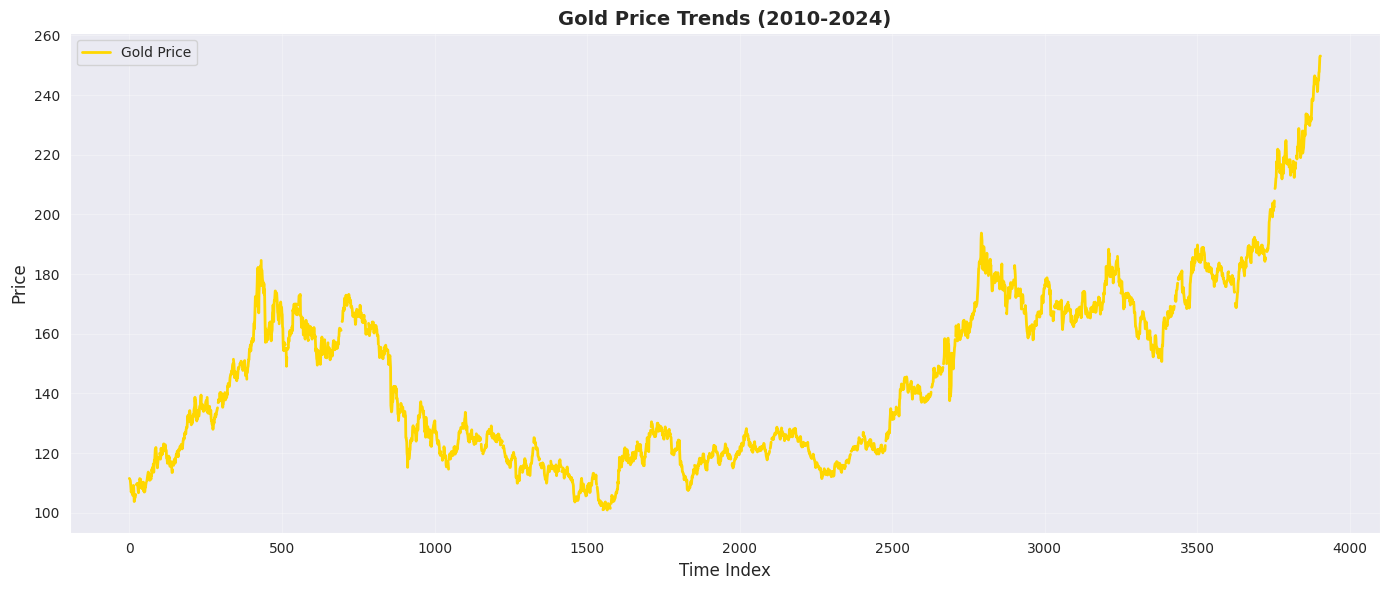

Plotted: 0       112.03
1       110.86
2          NaN
3       111.52
4       108.94
         ...  
3899    248.63
3900    251.27
3901    251.22
3902    253.93
3903    250.87
Name: gold close, Length: 3904, dtype: float64


In [23]:
# Create gold price trend plot
# Assuming there's a date column and a gold price column - adjust as needed
fig, ax = plt.subplots(figsize=(14, 6))

# Try to plot the first numeric column as price over index as time proxy
# Adjust this based on actual column names in your data
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(numeric_cols)

if len(numeric_cols) > 0:
    # Plot the first numeric column (likely price)
    ax.plot(df.index, df["gold open"], linewidth=2, color='gold', label='Gold Price')
    ax.set_xlabel('Time Index', fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title('Gold Price Trends (2010-2024)', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Plotted: {df["gold close"]}")
else:
    print("No numeric columns found for plotting")

## 6. Create Correlation Heatmap

Calculate the correlation matrix and visualize it as a heatmap using seaborn to identify relationships between variables.

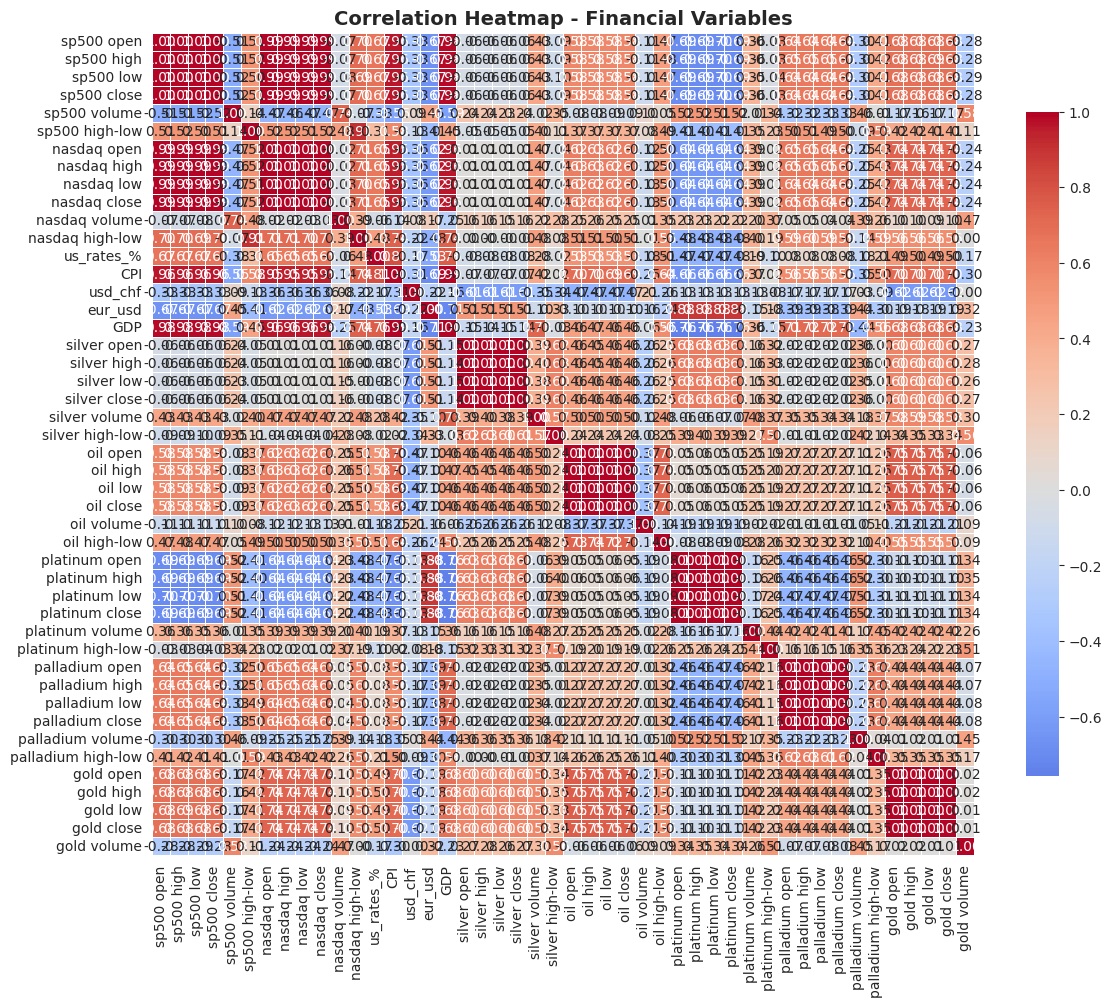

Correlation Matrix:
                    sp500 open  sp500 high  sp500 low  sp500 close  \
sp500 open            1.000000    0.999916   0.999889     0.999810   
sp500 high            0.999916    1.000000   0.999823     0.999880   
sp500 low             0.999889    0.999823   1.000000     0.999898   
sp500 close           0.999810    0.999880   0.999898     1.000000   
sp500 volume         -0.514871   -0.511390  -0.520291    -0.516595   
sp500 high-low        0.513681    0.520522   0.504377     0.511622   
nasdaq open           0.991532    0.991573   0.991320     0.991378   
nasdaq high           0.991454    0.991627   0.991262     0.991433   
nasdaq low            0.991491    0.991556   0.991461     0.991516   
nasdaq close          0.991358    0.991538   0.991325     0.991548   
nasdaq volume        -0.070258   -0.066025  -0.077327    -0.072500   
nasdaq high-low       0.698557    0.703390   0.691327     0.696559   
us_rates_%            0.668533    0.668830   0.670665     0.669840   


In [28]:
# Calculate correlation matrix for numeric columns
numeric_df = df.select_dtypes(include=[np.number])

if len(numeric_df.columns) > 1:
    correlation_matrix = numeric_df.corr()
    
    # Create correlation heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
                ax=ax)
    ax.set_title('Correlation Heatmap - Financial Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Correlation Matrix:")
    print(correlation_matrix)
else:
    print("Not enough numeric columns for correlation analysis")

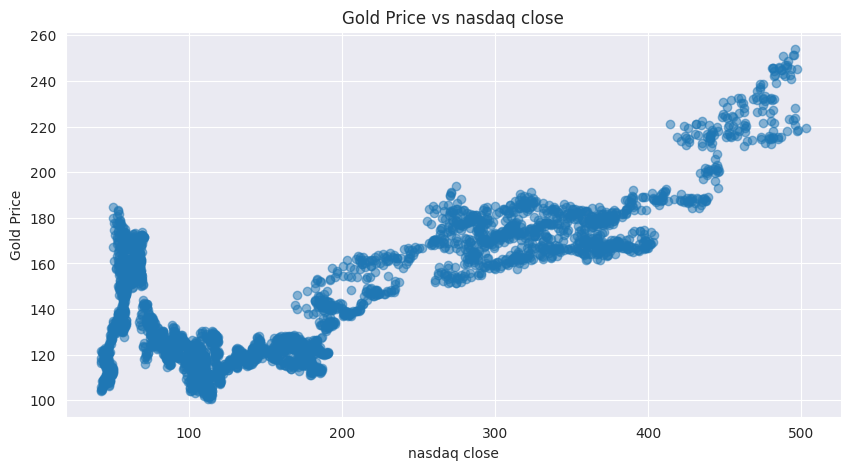

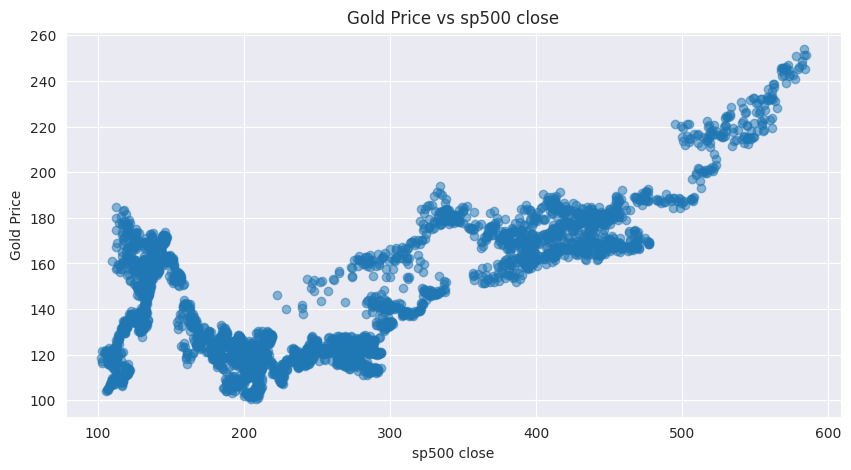

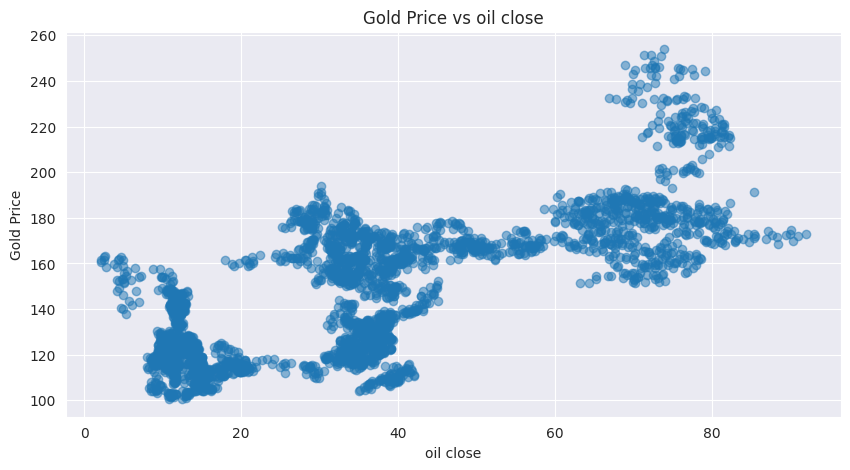

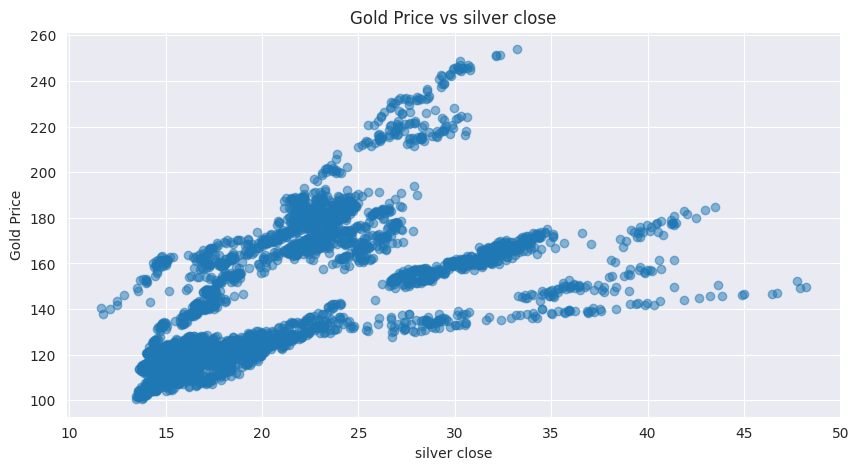

In [30]:
# Create scatter plots for relationships
variables_to_analyze = ['nasdaq close', 'sp500 close', 'oil close', 'silver close']  

for var in variables_to_analyze:
    if var in df.columns:
        plt.figure(figsize=(10, 5))
        plt.scatter(df[var], df['gold close'], alpha=0.5)
        plt.xlabel(var)
        plt.ylabel('Gold Price')
        plt.title(f'Gold Price vs {var}')
        plt.show()